# Drift Simulation

Assuming we only train on 2002 to 2017, how many timesteps will it take for each of the models to drift from an acceptable range?

Copyright 2026, Battelle Energy Alliance, LLC, ALL RIGHTS RESERVED

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
os.chdir("..")
from HelpingFunctions import ERCOTProcessor
from HelpingFunctions import WeatherProcessing
from HelpingFunctions import FeatureEngineering
from HelpingFunctions import ForecastingHelpers

import onnxruntime as ort
ort.set_default_logger_severity(4)
from mapie.regression import MapieRegressor
%matplotlib inline
plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['figure.dpi'] = 125

In [2]:
# Does not like processing between 2002-2024 in one go, split to allow for optimization
ercot_df_pt1 = ERCOTProcessor.fileprocessing(2002,2016)
ercot_df_pt2 = ERCOTProcessor.fileprocessing(2016,2024)
ercot_df = pd.concat([ercot_df_pt1, ercot_df_pt2])

In [3]:
# Process weather data
filename = 'ElectricityDemandAustinTX/LoadForecastingAttacks/Weather/weather_20022024.csv'
weather_df = pd.read_csv(filename).drop('Unnamed: 0', axis=1)
weather_df.columns = ['time', 'temp', 'humd', 'wnsp', 'cond']
weather_df.loc[:,'time'] = weather_df['time'].apply(lambda x: pd.to_datetime(x))
weather_df = weather_df.set_index('time')
weather_df.head()

,temp,humd,wnsp,cond
time,,,,
2002-01-01 00:00:00,36.0,0.64,7.0,0.0
2002-01-01 01:00:00,36.0,0.57,8.0,0.0
2002-01-01 02:00:00,36.0,0.57,8.0,0.0
2002-01-01 03:00:00,36.0,0.57,6.0,0.0
2002-01-01 04:00:00,35.0,0.61,8.0,0.0


In [4]:
# Concat weather and ERCOT data and deduplicate any values
full_df = FeatureEngineering.feature_engineering(weather_df, ercot_df)
full_df = full_df.drop_duplicates(subset=None, keep="last", inplace=False)
full_df = full_df[~full_df.index.duplicated()]

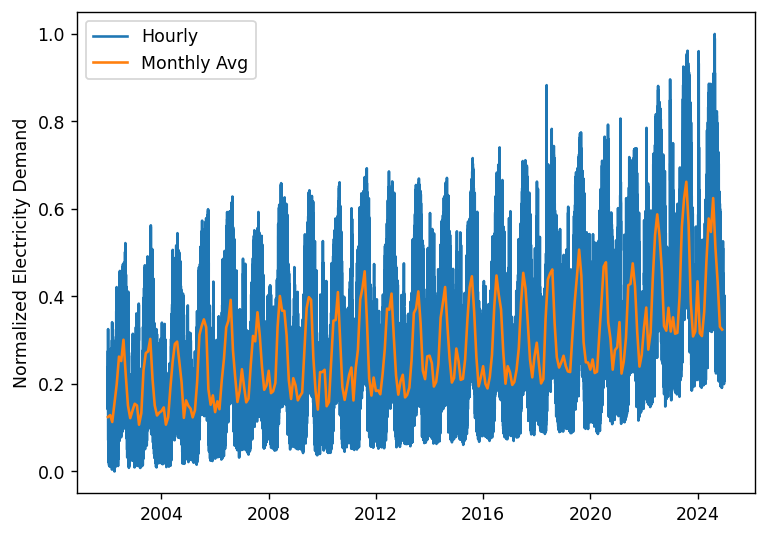

In [5]:
# Plot a monthly rolling average versus the true hourly value
monthly_norm = full_df['load'].resample('MS').mean().bfill()
plt.plot(full_df['load'], label='Hourly')
plt.plot(monthly_norm, label='Monthly Avg')
plt.ylabel('Normalized Electricity Demand')
plt.legend();

# MLP Regression

In [6]:
hourly_res_norm = ForecastingHelpers.hourlyresiduals(full_df)

In [7]:
# train-validate-test split
train = hourly_res_norm[:'2014']
validate = hourly_res_norm['2015':'2016']
test = hourly_res_norm['2017':]

# setup training variables 
exog_tr = train.iloc[:,1:].values
ar_tr = train['load'].shift().bfill().values[:,None]
X_tr = np.hstack([ar_tr, exog_tr])
y_tr = train['load'].values

# setup validation variables
exog_val = validate.iloc[:,1:].values
y_val = validate['load'].values

# setup testing variables
exog_te = test.iloc[:,1:].values

# setup miscellaneous variables
yp_full = hourly_res_norm.loc[:'2016','load']
yp_val = hourly_res_norm.loc['2015':'2016','load']
yp_te = hourly_res_norm.loc['2017':,'load']
y_init_val = np.hstack([y_tr[-1], validate.iloc[167::168,0].values])
y_init_te = np.hstack([y_val[-1], test.iloc[167::168,0].values])

## MLP Regression Grid Search

In [8]:
def compute_mae(y, yhat):
    """given predicted and observed values, computes mean absolute error"""
    return np.mean(np.abs(yhat - y))

def forecast(model, exog, y_init):
    """given a trained model, exogenous features, and initial AR term, makes forecasting predictions"""
    yhat = []
    Xi_te = np.hstack([y_init, exog[0]])[None,:]
    for i in range(len(exog)-1):
        yhat_i = model.predict(Xi_te)[0]
        yhat.append(yhat_i)
        Xi_te = np.hstack([yhat_i, exog[i+1]])[None,:]
    yhat.append(model.predict(Xi_te)[0])
    return np.array(yhat)
def weekly_forecast(model, exog, y_init):
    """given a trained model exogenous features, and initial AR term, makes a series of 1-week-out forecasts"""
    yhat = []
    for i, yi in enumerate(y_init):
        exog_i = exog[168*i:168*(i+1),:]
        if exog_i.shape[0] < 1:
            break
        yhat.append(forecast(model, exog_i, yi))
    return np.hstack(yhat)

In [9]:
from sklearn.neural_network import MLPRegressor

# train MLP model, and get validation set performance
def get_mlp_mae(hl, a, lr, mi):
    mod = MLPRegressor(hidden_layer_sizes=hl, alpha=a, learning_rate_init=lr, max_iter=mi)
    mod.fit(X_tr, y_tr)
    pred_val = weekly_forecast(mod, exog_val, y_init_val)
    return compute_mae(y_val, pred_val)

# define potential sets of hyperparameters
hidden_layer_sizes = [(100,),(500,),(100,10,),(100,100,)]
alpha = [0.0001, 0.00001, 0.001]
learning_rate = [0.0001, 0.001, 0.01]
max_iter = [200, 1000, 10000]
grid_search = pd.DataFrame(columns=['hl','a','lr','mi','mae'])

# perform grid search
for hl in hidden_layer_sizes:    
    for a in alpha:        
        for lr in learning_rate:
            for mi in max_iter:
                mae = get_mlp_mae(hl, a, lr, mi)
                params = {'hl':hl, 'a':a, 'lr':lr, 'mi':mi, 'mae':mae} 
                params_df = pd.DataFrame([params])
                grid_search = pd.concat([grid_search, params_df], ignore_index=True)

# display best hyperparameters based on grid search
grid_mlp = grid_search.sort_values('mae').head(1)

In [10]:
import joblib 

# best hyperparamters
hl, a, lr, mi  = grid_mlp['hl'].values[0], grid_mlp['a'].values[0], grid_mlp['lr'].values[0], grid_mlp['mi'].values[0]

# train model and get predictions
mod_mlp = MLPRegressor(hidden_layer_sizes=hl, alpha=a, learning_rate_init=lr, max_iter=mi)
mod_mlp.fit(X_tr, y_tr)

mapie_mlp = MapieRegressor(mod_mlp, method="naive")
mapie_mlp.fit(X_tr, y_tr)
pred_mapie, pred_ci = ForecastingHelpers.weekly_forecast(yp_val.index, mapie_mlp, exog_val, y_init_val, 0.05)
print('MAE:', ForecastingHelpers.compute_mae(y_val, pred_mapie))

# Save the model
filename = 'ElectricityDemandAustinTX/LoadForecastingAttacks/SaveFiles/mlp.joblib'
joblib.dump(mapie_mlp, filename)

MAE: 0.047507293577814386


['ElectricityDemandAustinTX/LoadForecastingAttacks/SaveFiles/mlp.joblib']

In [11]:
# Convert into ONNX format.
from skl2onnx import to_onnx

X_tr32 = X_tr[:1].astype(dtype="float32")

onx = to_onnx(mod_mlp, X_tr32)
with open("ElectricityDemandAustinTX/LoadForecastingAttacks/SaveFiles/mlp_no_mapie.onnx", "wb") as f:
    f.write(onx.SerializeToString())

In [12]:
# Predict forecasted values for testing
pred_mapie_te, pred_ci_te = ForecastingHelpers.weekly_forecast(yp_te.index, mapie_mlp, exog_te, y_init_te, 0.05)
#pred_mapie_te = weekly_forecast(mod_mlp, exog_te, y_init_te)

MAE: 0.05393932306499573


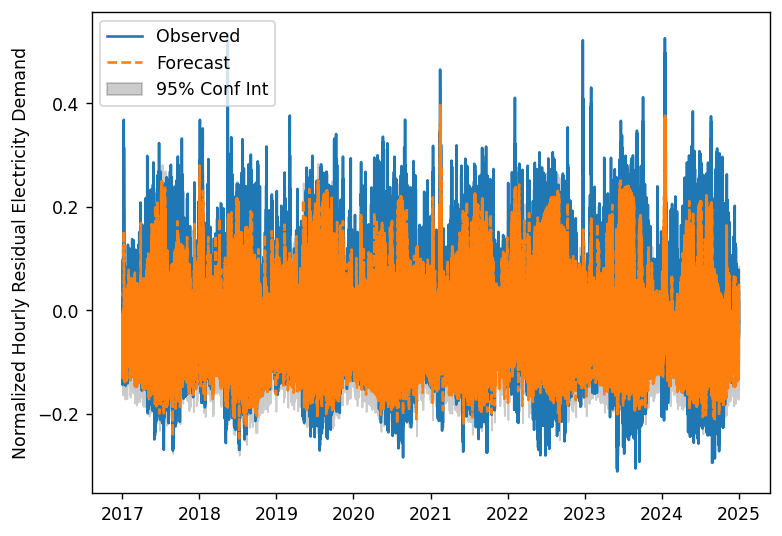

In [13]:
# plotting testing
print('MAE:', ForecastingHelpers.compute_mae(yp_te, pred_mapie_te))
ForecastingHelpers.plot_full(yp_te, pred_mapie_te, yp_te.index, pred_ci_te)

In [14]:
# Convert prediction and confidence interval for validation and testing datasets to Pandas Dataframes 
# to be used to find the deviation of the confidence interval width
pred_df = pd.DataFrame(data=pred_mapie, index=yp_val.index, columns=['load'])
pred_test = pd.DataFrame(data=pred_mapie_te, index=yp_te.index, columns=['load'])
preds_mlp = pd.concat([pred_df, pred_test])
ci = pd.concat([pred_ci, pred_ci_te])
preds_np = preds_mlp['load']
normals = pd.concat([yp_val, yp_te])

In [15]:
# Get the confidence interval width (c_x) right after training and validation and compare to the confidence interval width iterated to the point where
# the width of the interval exceeds the width of c_x, labeling it 'div' as the point at which a division happens.
for i, index_label in enumerate(pred_ci_te.index):
        lb = pred_ci_te.iloc[i,0]
        ub = pred_ci_te.iloc[i,1]
        c_x = pred_ci.iloc[-1,1]-pred_ci.iloc[-1,0]
        if ub-lb > c_x:
            div = index_label
            load_div = preds_np[i]
            break
        else:
            div = ci.index[-1]

div

Timestamp('2017-01-01 06:00:00')

In [16]:
# Calculate the KL Divergence using SciPy's KL divergence modeling technique, where 
diverge = ForecastingHelpers.calculateKLDivergence(yp_te,preds_mlp['load'])
med_drift, high_drift = ForecastingHelpers.testDivergence(diverge, yp_te)
med_drift

Timestamp('2017-01-04 19:00:00')

In [17]:
# PSI, which is a deviation of KL divergence can be used to determe drift, it is the symmetric version of KL divergence.
psi = ForecastingHelpers.calculatePSI(yp_te, preds_mlp['load'])
med_PSI, high_PSI = ForecastingHelpers.testPSI(psi, yp_te)
med_PSI

Timestamp('2017-01-06 19:00:00')

In [18]:
print("Exceeds confidence interval: "  + str(ForecastingHelpers.MTTF(pred_df, div)) + " Exceeds 0.1 divergence: " + str(ForecastingHelpers.MTTF(pred_df, med_drift)))

Exceeds confidence interval: 731 days 06:00:00 Exceeds 0.1 divergence: 734 days 19:00:00


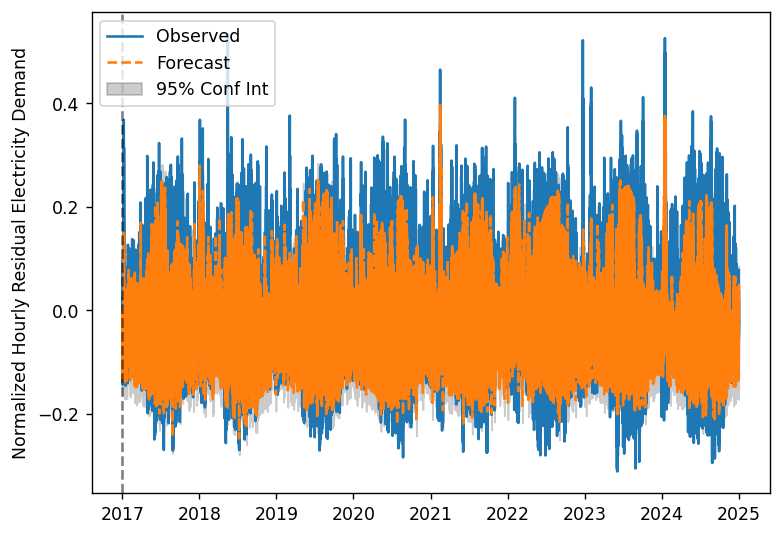

In [19]:
ForecastingHelpers.plot_full_w_div(yp_te, pred_mapie_te, yp_te.index, pred_ci_te, div)

Calculate KL Divergence for Monthly Forecasts to Compare to SARIMA

In [20]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

load_min, load_max = full_df['load'].min(), full_df['load'].max()
temp_min, temp_max = full_df['temp'].min(), full_df['temp'].max()
wnsp_min, wnsp_max = full_df['wnsp'].min(), full_df['wnsp'].max()


# best hyperparameters from grid search
best_monthly_order = (1,1,1)
best_monthly_seas_order = (0,1,1,12)


# monthly average forecasts
train_m = monthly_norm[:'2016']
test_m = monthly_norm['2017':]
model_m = SARIMAX(train_m, order=best_monthly_order, seasonal_order=best_monthly_seas_order).fit()
forecast_m = model_m.get_forecast(steps=len(test_m))
pred_m_norm = pd.Series(forecast_m.predicted_mean, index=test_m.index)

# baseline hourly residual forecasts
idx = test.index[::168]
idx = idx.append(pd.DatetimeIndex(['2017-12-31 23']))
pred_base = pd.Series(np.hstack([y_init_te, yp_te.iloc[-1]]), index=idx)
pred_base = pred_base.resample('H').ffill().values

In [21]:
# dataframe of montly forecasts
m_norm_df = pd.DataFrame({'m_norm':pred_m_norm, 'month':pred_m_norm.index.month, 'year':pred_m_norm.index.year})

mlp_norm_df = pd.DataFrame({'h_norm':pred_test['load'], 'month':test.index.month, 'year':test.index.year})
pred_mlp_norm_df = mlp_norm_df.merge(m_norm_df, on=['month','year'])
pred_mlp_norm = pd.Series((pred_mlp_norm_df['m_norm'] + pred_mlp_norm_df['h_norm']).values, index=test.index)
pred_mlp = pred_mlp_norm * (load_max - load_min) + load_min

In [22]:
# Downsample to a monthly basis to reduce KL and PSI sensitivity
sampled_pred = pred_mlp.resample('MS').mean().bfill()

In [23]:
# Calculate the KL Divergence using SciPy's KL divergence modeling technique, where 
diverge = ForecastingHelpers.calculateKLDivergence(monthly_norm,sampled_pred)
med_drift, high_drift = ForecastingHelpers.testDivergence(diverge, monthly_norm)
med_drift

Timestamp('2018-11-01 00:00:00')

In [24]:
sampled_ci = pred_ci.resample('MS').mean().bfill()
sampled_ci_te = pred_ci_te.resample('MS').mean().bfill()

In [25]:
# Get the confidence interval width (c_x) right after training and validation and compare to the confidence interval width iterated to the point where
# the width of the interval exceeds the width of c_x, labeling it 'div' as the point at which a division happens.
for i, index_label in enumerate(sampled_ci_te.index):
        lb = sampled_ci_te.iloc[i,0]
        ub = sampled_ci_te.iloc[i,1]
        c_x = sampled_ci.iloc[-1,1]-sampled_ci.iloc[-1,0]
        if ub-lb > c_x:
            div = index_label
            load_div = preds_np[i]
            break
        else:
            div = sampled_ci.index[-1]

div

Timestamp('2017-04-01 00:00:00')

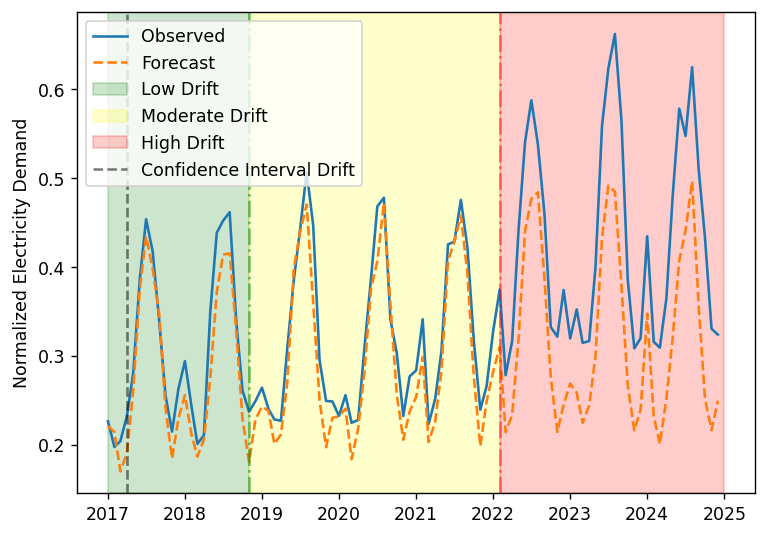

In [26]:
plt.plot(monthly_norm['2017':], label='Observed')
plt.plot(sampled_pred, label='Forecast', ls='--')
plt.axvline(x=med_drift, color="green", alpha=0.5, linestyle="-.")
plt.axvline(x=high_drift, color="red", alpha=0.5, linestyle="-.")
plt.axvspan(pred_mlp.index[0],med_drift, color='green', alpha=0.2, label="Low Drift")
plt.axvspan(med_drift,high_drift, color='yellow', alpha=0.2, label="Moderate Drift")
plt.axvspan(high_drift,pred_mlp.index[-1], color='red', alpha=0.2, label="High Drift")
plt.axvline(x=div, color="black", alpha=0.5, linestyle="--", label="Confidence Interval Drift")
plt.legend()
plt.ylabel('Normalized Electricity Demand')
plt.legend();

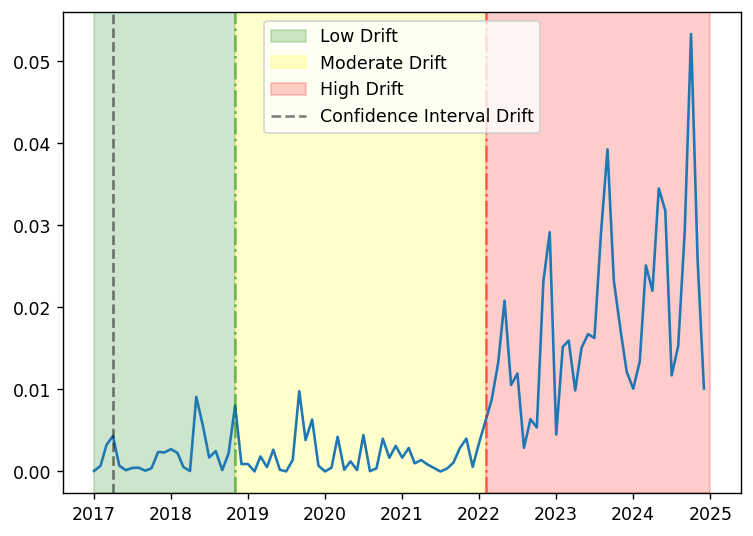

In [27]:
import matplotlib.pyplot as plt
plt.plot(diverge)
plt.axvline(x=med_drift, color="green", alpha=0.5, linestyle="-.")
plt.axvline(x=high_drift, color="red", alpha=0.5, linestyle="-.")
plt.axvspan(pred_mlp.index[0],med_drift, color='green', alpha=0.2, label="Low Drift")
plt.axvspan(med_drift,high_drift, color='yellow', alpha=0.2, label="Moderate Drift")
plt.axvspan(high_drift,pred_mlp.index[-1], color='red', alpha=0.2, label="High Drift")
plt.axvline(x=div, color="black", alpha=0.5, linestyle="--", label="Confidence Interval Drift")
plt.legend()

## Simulate KL divergence smoothing in "green zone"

In [28]:
# Calculate for 2017 to 2018
# Predict forecasted values for testing
diverge_orig = ForecastingHelpers.calculateKLDivergence(monthly_norm['2017':'2018'],sampled_pred['2017':'2018'])
high_drift, med_drift, diverge = ForecastingHelpers.predictKL(diverge_orig)

In [29]:
high_drift

Timestamp('2020-05-01 00:00:00')

In [30]:
med_drift

Timestamp('2018-11-01 00:00:00')

In [32]:
full_diverge = ForecastingHelpers.calculateKLDivergence(monthly_norm,sampled_pred)

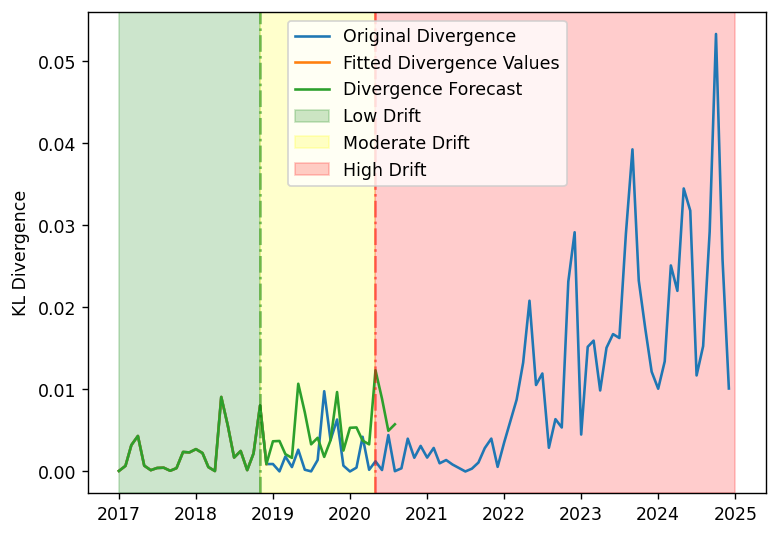

In [34]:
plt.plot(full_diverge, label='Original Divergence')
plt.plot(diverge_orig, label='Fitted Divergence Values')
plt.plot(diverge, label='Divergence Forecast')
plt.ylabel('KL Divergence')
plt.axvline(x=med_drift, color="green", alpha=0.5, linestyle="-.")
plt.axvspan(pred_mlp.index[0],med_drift, color='green', alpha=0.2, label="Low Drift")
plt.axvspan(med_drift,high_drift, color='yellow', alpha=0.2, label="Moderate Drift")
plt.axvspan(high_drift,pred_mlp.index[-1], color='red', alpha=0.2, label="High Drift")
plt.axvline(x=high_drift, color="red", alpha=0.5, linestyle="-.")
plt.legend()
plt.show()

In [ ]:
#mae_threshold = ForecastingHelpers.compute_mae(y_val, pred_mapie)*0.9
#mae_drift = (np.abs(sampled_pred - test_m)).cumsum()/len(test_m)
#rmse_drift = np.sqrt(((sampled_pred - test_m).cumsum()**2)/len(test_m))
#mae_point = mae_drift.index[mae_drift.searchsorted(mae_threshold)]
#rmse_threshold = np.sqrt(np.mean((y_val - pred_mapie) ** 2))*0.9
#rmse_point = rmse_drift.index[rmse_drift.searchsorted(rmse_threshold)]
#print(div)
#print(med_drift)
#print(rmse_point)

## Simulate KL divergence smoothing in "Yellow Zone"

In [40]:
# Calculate for 2017 to 2020
# Predict forecasted values for testing
diverge_orig = ForecastingHelpers.calculateKLDivergence(monthly_norm['2017':'2020'],sampled_pred['2017':'2020'])
high_drift, med_drift, diverge = ForecastingHelpers.predictKL(diverge_orig)

In [41]:
high_drift

Timestamp('2022-03-01 00:00:00')

In [42]:
med_drift

Timestamp('2018-11-01 00:00:00')

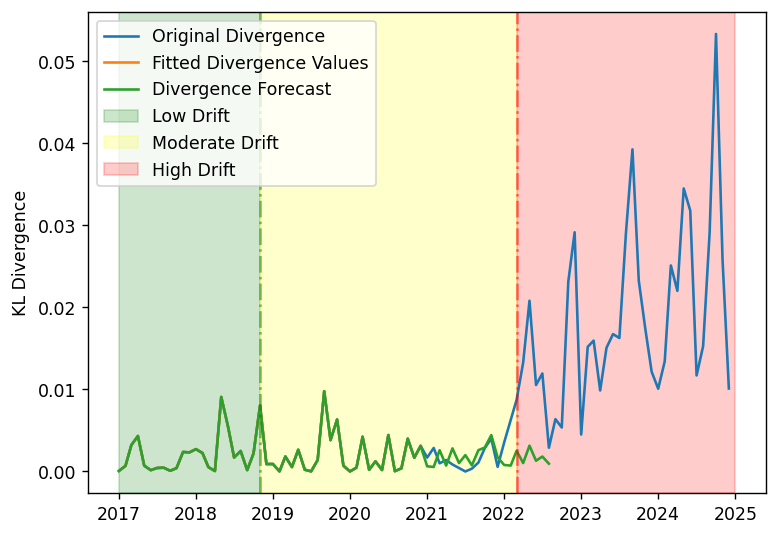

In [43]:
plt.plot(full_diverge, label='Original Divergence')
plt.plot(diverge_orig, label='Fitted Divergence Values')
plt.plot(diverge, label='Divergence Forecast')
plt.ylabel('KL Divergence')
plt.axvline(x=med_drift, color="green", alpha=0.5, linestyle="-.")
plt.axvspan(pred_mlp.index[0],med_drift, color='green', alpha=0.2, label="Low Drift")
plt.axvspan(med_drift,high_drift, color='yellow', alpha=0.2, label="Moderate Drift")
plt.axvspan(high_drift,pred_mlp.index[-1], color='red', alpha=0.2, label="High Drift")
plt.axvline(x=high_drift, color="red", alpha=0.5, linestyle="-.")
plt.legend()
plt.show()

## Simulate KL Divergence Smoothing in "Red Zone"

In [44]:
# Calculate for 2017 to 2023
# Predict forecasted values for testing
diverge_orig = ForecastingHelpers.calculateKLDivergence(monthly_norm['2017':'2023'],sampled_pred['2017':'2023'])
high_drift, med_drift, diverge = ForecastingHelpers.predictKL(diverge_orig)

In [45]:
high_drift

Timestamp('2022-02-01 00:00:00')

In [46]:
med_drift

Timestamp('2018-11-01 00:00:00')

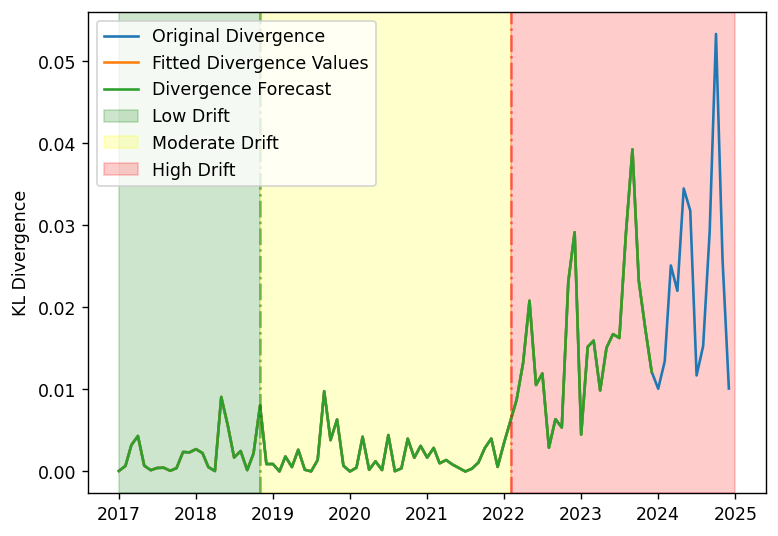

In [47]:
plt.plot(full_diverge, label='Original Divergence')
plt.plot(diverge_orig, label='Fitted Divergence Values')
plt.plot(diverge, label='Divergence Forecast')
plt.ylabel('KL Divergence')
plt.axvline(x=med_drift, color="green", alpha=0.5, linestyle="-.")
plt.axvspan(pred_mlp.index[0],med_drift, color='green', alpha=0.2, label="Low Drift")
plt.axvspan(med_drift,high_drift, color='yellow', alpha=0.2, label="Moderate Drift")
plt.axvspan(high_drift,pred_mlp.index[-1], color='red', alpha=0.2, label="High Drift")
plt.axvline(x=high_drift, color="red", alpha=0.5, linestyle="-.")
plt.legend()
plt.show()